## Sediment transport at Duke

Logic: [`utils/gcm_comparison.py`](utils/gcm_comparison.py) (GCM/buoy comparisons). Sediment transport & wave roses: [`utils/sediment_transport_NC.py`](utils/sediment_transport_NC.py).

**Data split:** BinWaves + KMA **bulk** from `grid4/outputs/BinWaves_BMUS/`; ShoreShop **partitions** from `merged_grids`. Run cell 3 once per session to set `_HIST_KW`.

Each cell below is an independent example — change the arguments and re-run.

| Parameter | Options |
|-----------|--------|
| `aggregation` | `"daily"`, `"monthly"`, `"native"` (avoid native on long ranges) |
| `interactive` / `static` | Plotly and/or matplotlib |
| `models` | list of scenario labels, or `None` = all with `enabled=True` in catalogue |
| `time_start` / `time_end` | e.g. `"2015-01-01"`, `None` for full series |
| `variable` | `"hs"` or `["hs", "tp", "dp"]` for stacked subplots (n rows × 1 col) |
| `plot_longshore_transport` | Qs from Hs+Dp; `shoreline_orientation_deg` scalar, list, or dict per coordinate |


In [1]:
# Run once per kernel session — ensures `import utils.*` resolves to grid4/utils/
import sys
from pathlib import Path

_GRID4 = Path("/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4").resolve()
if str(_GRID4) not in sys.path:
    sys.path.insert(0, str(_GRID4))



### Build reusable BinWaves + KMA bulk grids (`BinWaves_BMUS` format)

Run **once** to create `outputs/BinWaves_BMUS/` (`hs/tp/dp_grid{N}_BinWaves_BMUS.nc`).
**Bulk** hindcast (Hs/Tp/Dp/Dm with KMA) uses that folder via `_HIST_KW['historical_folder']`.
**Partitions** (`phs0`, `phs1`, …) and original BinWaves reference overlays still read ShoreShop `merged_grids`.

Full domain (~1980–2023) takes ~1–2 h. Test subset first with `--max-sites` / `--time-start`.


In [2]:
# One-time build (uncomment to run; or: bash utils/build_kma_merged_grids.sh)
# !cd /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4 && \
# PYTHONPATH=. python3 -m utils.build_kma_merged_grids \
#   --input-folder /lustre/geocean/WORK/users/montanoj/personal/ShoreShop2026/outputs/cropped_variables \
#   --output-folder outputs/BinWaves_BMUS \
#   --grid-id 4 \
#   --project-root /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4 \
#   --overwrite

BINWAVES_BMUS = "/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus"

# Bulk hindcast (BinWaves + KMA): new pre-built NetCDFs in BinWaves_BMUS.
# Partitions / original BinWaves reference: ShoreShop merged_grids (default).
_HIST_KW = dict(
    historical_folder=str(BINWAVES_BMUS),
    partitions_dataset="merged_grids",
    project_root=_GRID4,
)


In [3]:
# coord = NDBC buoy (lon, lat); waves = merged hindcast Hs/Dp site (lon, lat);
# site_index = grid site id (optional); sn = shore-normal azimuth (° from N, clockwise) for Qs
buoys = {
    "44056": {
        "coord": (-75.7140, 36.2000),
        "waves": (-75.714, 36.200),
        "site_index": 1669,
        "sn": 72,
    },
    "jprn7": {
        "coord": (-75.5870, 35.9120),
        "waves": (-75.587, 35.912),
        "sn": 65,
    },
    "44014": {
        "coord": (-74.837, 36.603),
        "waves": (-74.813, 36.579),
        "site_index": 2960,
        "sn": 72,
    },
    "44019": {
        "coord": (-75.200, 36.400),
        "waves": (-75.200, 36.400),
        "site_index": 2964,
        "sn": 72,
    },
    "44006": {
        "coord": (-75.400, 36.300),
        "waves": (-75.400, 36.300),
        "site_index": 2963,
        "sn": 72,
    },
    "44100": {
        "coord": (-75.593, 36.258),
        "waves": (-75.593, 36.258),
        "site_index": 1670,
        "sn": 72,
    },
}


In [6]:
# Total cumulative Qs map (overlay NDBC buoys when `buoys` dict is defined below)
import importlib
import matplotlib.pyplot as plt
import utils.sediment_transport_NC as st
importlib.reload(st)


<module 'utils.sediment_transport_NC' from '/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4/utils/sediment_transport_NC.py'>

Selected 325 hindcast sites inside polygon
Region cumulative Qs (deep, DP): 325 sites, theta=72.0°, K_2=0.15, daily, 1980-01-01 – 2023-12-31


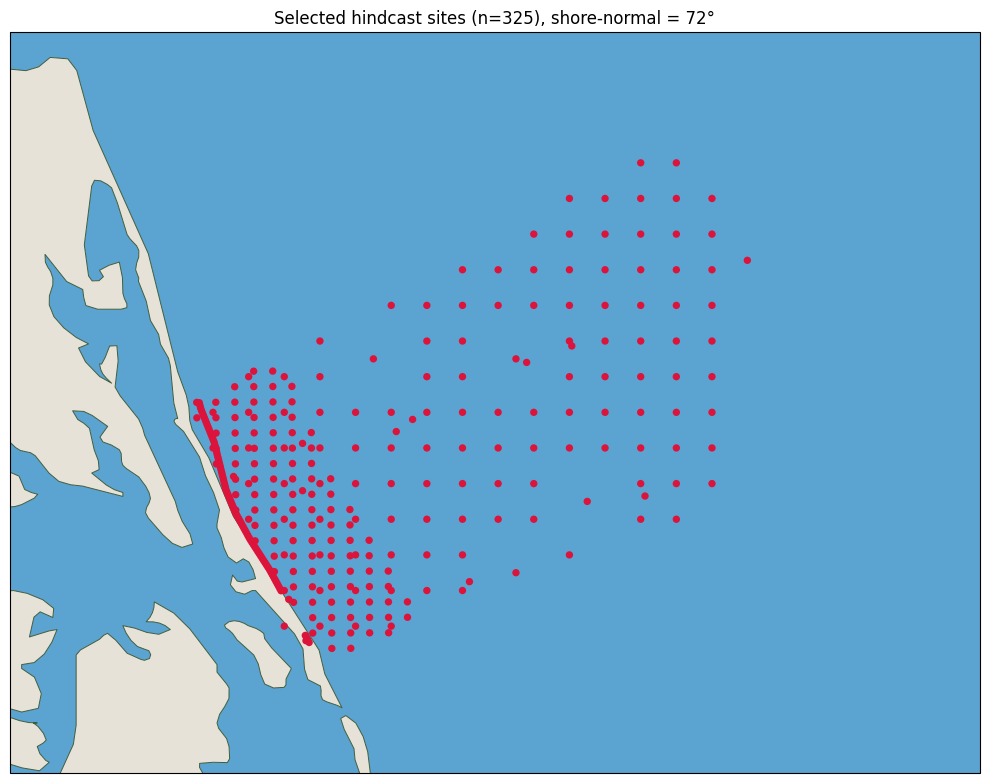

In [7]:
# Cumulative sediment transport — hindcast sites inside polygon
import sys
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

_GRID4 = Path("/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4").resolve()
if str(_GRID4) not in sys.path:
    sys.path.insert(0, str(_GRID4))

# Uses `BINWAVES_BMUS` / `_HIST_KW` from cell 3 (re-run that cell if undefined)
if "_HIST_KW" not in globals():
    BINWAVES_BMUS = "/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus"
    _HIST_KW = dict(
        historical_folder=str(BINWAVES_BMUS),
        partitions_dataset="merged_grids",
        project_root=_GRID4,
    )

import utils.sediment_transport_NC as st
importlib.reload(st)

# Polygon corners as (lon, lat)
DUCK_POLYGON_LONLAT = [
    (-75.818, 36.31),
    (-74.93, 36.80),
    (-74.54, 36.27),
    (-75.60, 35.86),
]

SHORE_NORMAL_DEG = 72  # shore-normal (° from N), same at all sites

# qs_formula: "cerc" (default) or "deep" (needs Tp; uses Hs, Tp, direction)
QS_FORMULA = "deep"  # "deep" for K_2 * Tp^(1/5) * Hs^(12/5) * cos^(6/5)(phi-theta) * sin(phi-theta)

# wave_direction: "dp" = peak dir (higher-energy component) or "dm" = mean dir (energy-weighted)
WAVE_DIRECTION = "dp"  # set to "dm" to use dm_grid4_BinWaves_BMUS.nc from KMA bulk grids

region_qs = st.compute_region_cumulative_qs(
    DUCK_POLYGON_LONLAT,
    qs_formula=QS_FORMULA,
    wave_direction=WAVE_DIRECTION,
    shoreline_orientation_deg=SHORE_NORMAL_DEG,
    K=.15,
    aggregation="daily",
    cumulative_reference_start="1980-01-01",
    include_partitions=False,
    include_bulk=True,
    **_HIST_KW,
)

st.plot_region_sites_map(region_qs)
plt.show()


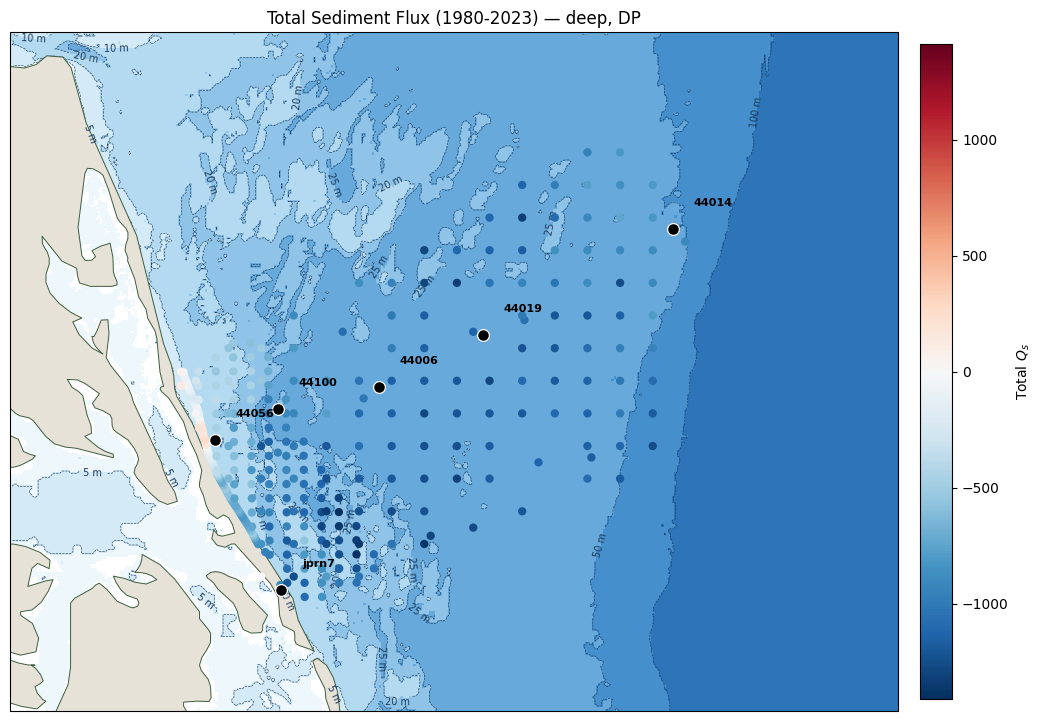

In [8]:
# Total cumulative Qs map (overlay NDBC buoys when `buoys` dict is defined below)
import importlib
import matplotlib.pyplot as plt
import utils.sediment_transport_NC as st
importlib.reload(st)
_map_kw = {
    "bathymetry_nc": "inputs/gebco_bathymetry.nc",
    "bathymetry_depth_bounds": (0, 5, 10, 20, 25, 50, 100, 400),
    "bathymetry_contour_levels": (5, 10, 20, 25, 50, 100),
    "buoy_color": "black",
}
if "buoys" in globals():
    _map_kw["buoys"] = buoys
st.plot_region_cumulative_qs_map(region_qs, **_map_kw)
plt.show()


### Qs with mean direction

Selected 325 hindcast sites inside polygon
Region cumulative Qs (deep, DM): 325 sites, theta=72.0°, K_2=0.15, daily, 1980-01-01 – 2023-12-31


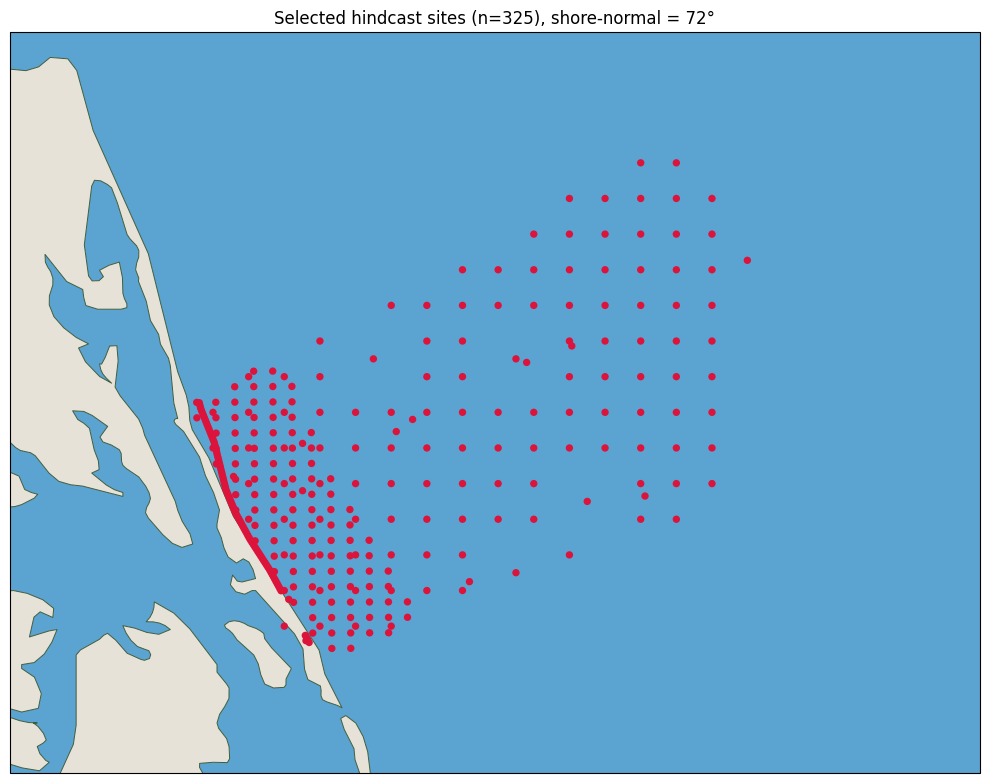

In [9]:
# Cumulative sediment transport — hindcast sites inside polygon
import sys
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

_GRID4 = Path("/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/grid4").resolve()
if str(_GRID4) not in sys.path:
    sys.path.insert(0, str(_GRID4))

# Uses `BINWAVES_BMUS` / `_HIST_KW` from cell 3 (re-run that cell if undefined)
if "_HIST_KW" not in globals():
    BINWAVES_BMUS = "/lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus"
    _HIST_KW = dict(
        historical_folder=str(BINWAVES_BMUS),
        partitions_dataset="merged_grids",
        project_root=_GRID4,
    )

import utils.sediment_transport_NC as st
importlib.reload(st)

# Polygon corners as (lon, lat)
DUCK_POLYGON_LONLAT = [
    (-75.818, 36.31),
    (-74.93, 36.80),
    (-74.54, 36.27),
    (-75.60, 35.86),
]

SHORE_NORMAL_DEG = 72  # shore-normal (° from N), same at all sites

# qs_formula: "cerc" (default) or "deep" (needs Tp; uses Hs, Tp, direction)
QS_FORMULA = "deep"  # "deep" for K_2 * Tp^(1/5) * Hs^(12/5) * cos^(6/5)(phi-theta) * sin(phi-theta)

# wave_direction: "dp" = peak dir (higher-energy component) or "dm" = mean dir (energy-weighted)
WAVE_DIRECTION = "dm"  # set to "dm" to use dm_grid4_BinWaves_BMUS.nc from KMA bulk grids

region_qs = st.compute_region_cumulative_qs(
    DUCK_POLYGON_LONLAT,
    qs_formula=QS_FORMULA,
    wave_direction=WAVE_DIRECTION,
    shoreline_orientation_deg=SHORE_NORMAL_DEG,
    K=.15,
    aggregation="daily",
    cumulative_reference_start="1980-01-01",
    include_partitions=False,
    include_bulk=True,
    **_HIST_KW,
)

st.plot_region_sites_map(region_qs)
plt.show()


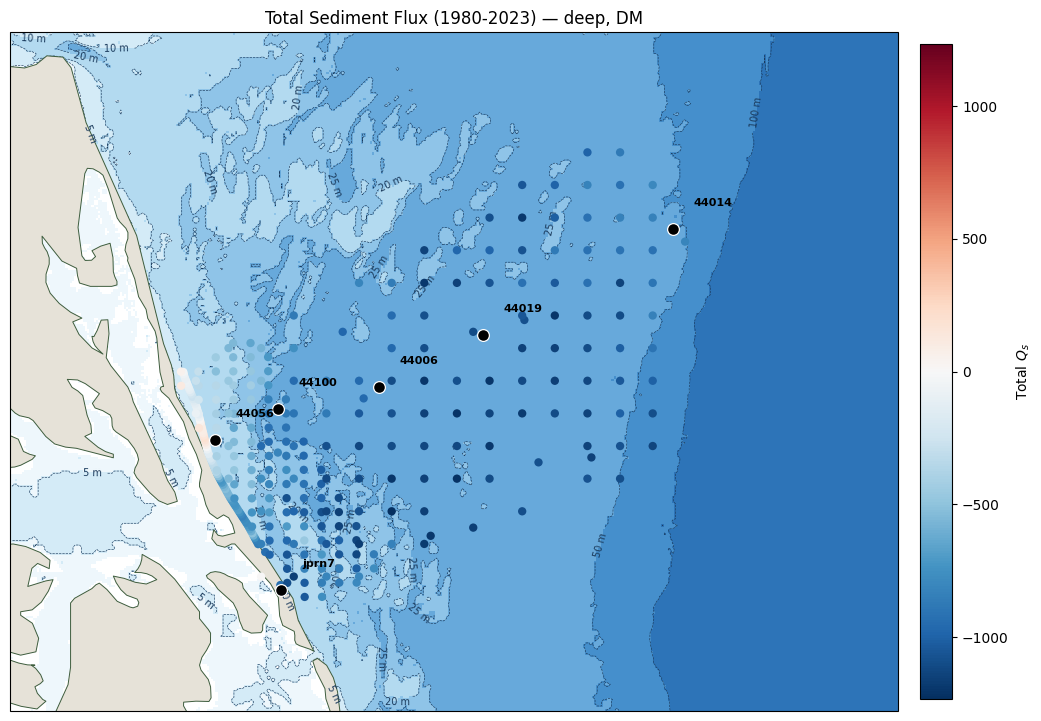

In [10]:
# Total cumulative Qs map (overlay NDBC buoys when `buoys` dict is defined below)
import importlib
import matplotlib.pyplot as plt
import utils.sediment_transport_NC as st
importlib.reload(st)
_map_kw = {
    "bathymetry_nc": "inputs/gebco_bathymetry.nc",
    "bathymetry_depth_bounds": (0, 5, 10, 20, 25, 50, 100, 400),
    "bathymetry_contour_levels": (5, 10, 20, 25, 50, 100),
    "buoy_color": "black",
}
if "buoys" in globals():
    _map_kw["buoys"] = buoys
st.plot_region_cumulative_qs_map(region_qs, **_map_kw)
plt.show()


### Buoy Data vs BinWaves + KMA clusters

Density scatter validation (Hs, Tp, Dir) saved under
`outputs/Figures/buoy_validation_binwaves_kma/`.
Uses `_HIST_KW` hindcast bulk; re-run after the full BinWaves_BMUS build completes.


In [11]:
buoys = {
    'SSBN7': (-78.484, 33.838),
    '41119': (-78.483, 33.842),
    'OCPN7': (-78.147, 33.911),
    '41108': (-78.016, 33.721), 
    '41013': (-77.764, 33.441),
    '41110': (-77.715, 34.142),
    '41109': (-77.300, 34.484),
    '41035': (-77.281, 34.476),
    '41036': (-76.949, 34.207),
    '41159': (-76.944, 34.211),
    '41007': (-76.5, 34.2),
    
    'jprn7': (-75.5870, 35.9120),
    '41017': (-75.1000, 35.4000),
    '41015': (-75.3000, 35.4000),
    '41120': (-75.2580, 35.2580),
    'dsln7': (-75.2970, 35.1530),
    '41025': (-75.4540, 35.0100),
    '44095': (-75.3300, 35.7500),
    '44086': (-75.3300, 35.7500),

    '44006': (-75.4000, 36.3000),
    '44079': (-75.5930, 36.1750),
    '44056': (-75.7140, 36.2000),
    '44100': (-75.5930, 36.2580),
    '44019': (-75.2000, 36.4000),
    '44014':(-74.837, 36.603),
    '44088': (-74.839, 36.612),

}

In [ ]:
# Buoy vs hindcast bulk validation scatter (Hs, Tp, Dir) — ShoreShop-style panels
import importlib
import utils.gcm_comparison as gc
importlib.reload(gc)

BUOY_VALIDATION_OUT = _GRID4 / "outputs/Figures/buoy_validation_binwaves_kma"

gc.plot_buoy_bulk_validation_scatter(
    list(buoys.keys()),
    buoys=buoys,
    aggregation="hourly",
    use_buoy_time_range=True,
    output_folder=BUOY_VALIDATION_OUT,
    save=True,
    show=False,
    **_HIST_KW,
)


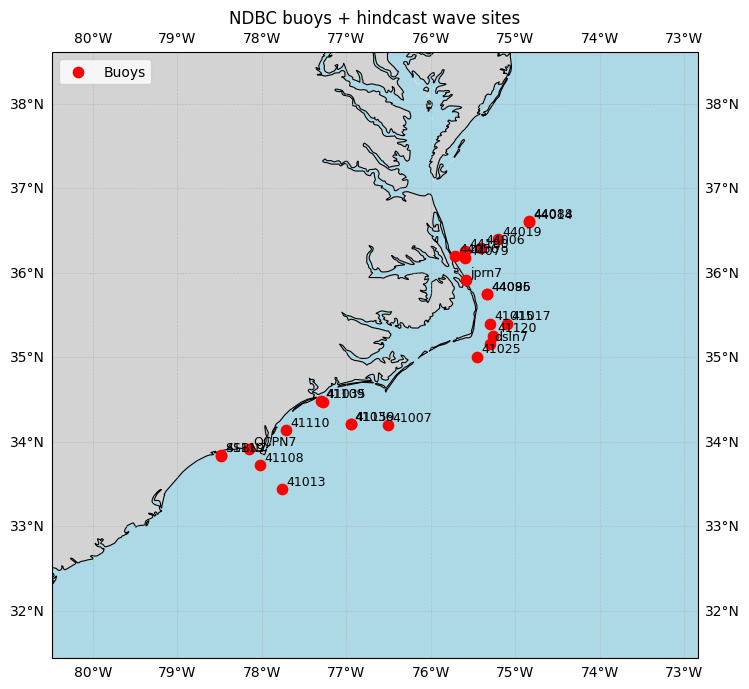

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import utils.gcm_comparison as gc

# Uses `buoys` + `extra_targets` from cells above.
buoys_plus = dict(buoys)
locations = gc.normalize_buoy_locations(buoys_plus)
wave_sites = gc.buoy_wave_locations_from_catalog(buoys_plus)
labels = list(locations.keys())

base_ids = [k for k in buoys.keys() if k in locations]
extra_ids = [k for k in labels if k not in base_ids]

base_coords = [locations[k] for k in base_ids]
extra_coords = [locations[k] for k in extra_ids]

wave_coords = []
wave_labels = []
for bid in base_ids:
    w = wave_sites[bid]
    if w["wave_lat"] is not None and w["wave_lon"] is not None:
        wave_coords.append((float(w["wave_lat"]), float(w["wave_lon"])))
        sid = w.get("wave_site_index")
        wave_labels.append(f"{bid} waves" + (f" (site {sid})" if sid is not None else ""))

all_coords = [locations[k] for k in labels] + wave_coords
all_lats = [lat for lat, lon in all_coords]
all_lons = [lon for lat, lon in all_coords]

fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min(all_lons) - 2, max(all_lons) + 2, min(all_lats) - 2, max(all_lats) + 2], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.6)

if base_coords:
    base_lats = [lat for lat, lon in base_coords]
    base_lons = [lon for lat, lon in base_coords]
    ax.scatter(base_lons, base_lats, color="red", s=55, transform=ccrs.PlateCarree(), zorder=3, label="Buoys")

if wave_coords:
    wave_lats = [lat for lat, lon in wave_coords]
    wave_lons = [lon for lat, lon in wave_coords]
    ax.scatter(
        wave_lons,
        wave_lats,
        color="dodgerblue",
        s=70,
        marker="^",
        edgecolor="white",
        linewidth=0.6,
        transform=ccrs.PlateCarree(),
        zorder=4,
        label="Hindcast waves",
    )
    for bid, (blat, blon) in zip(base_ids, base_coords):
        w = wave_sites[bid]
        if w["wave_lat"] is None or w["wave_lon"] is None:
            continue
        wlat, wlon = float(w["wave_lat"]), float(w["wave_lon"])
        if abs(blat - wlat) > 1e-4 or abs(blon - wlon) > 1e-4:
            ax.plot(
                [blon, wlon],
                [blat, wlat],
                color="0.45",
                linewidth=0.9,
                linestyle="--",
                transform=ccrs.PlateCarree(),
                zorder=2,
            )

if extra_coords:
    extra_lats = [lat for lat, lon in extra_coords]
    extra_lons = [lon for lat, lon in extra_coords]
    ax.scatter(extra_lons, extra_lats, color="gold", edgecolor="black", s=60, marker="^", transform=ccrs.PlateCarree(), zorder=4, label="Extra targets")

for label, (lat, lon) in zip(labels, [locations[k] for k in labels]):
    ax.text(lon + 0.05, lat + 0.05, label, transform=ccrs.PlateCarree(), fontsize=9)
for label, (lat, lon) in zip(wave_labels, wave_coords):
    ax.text(lon + 0.05, lat - 0.08, label, transform=ccrs.PlateCarree(), fontsize=8, color="dodgerblue")

ax.legend(loc="upper left")

ax.set_title("NDBC buoys + hindcast wave sites")
plt.tight_layout()
plt.show()


### Longshore transport (Qs from Hs + Dp)

Hindcast **bulk** (fuchsia) uses pre-built **BinWaves + KMA** NetCDFs in `BINWAVES_BMUS`.
Partition columns and the original BinWaves reference line use ShoreShop `merged_grids`.


Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44056 @ (36.200, -75.714) → historical (36.200, -75.714), 0.0 km [historical_grid, site 1669] | period 2012-01-01 – 2024-12-31
  Shoreline @ (36.200, -75.714) [Natural Earth coast, 2.45 km to coast]:
    Beach alongshore direction: 342.1° (from N, clockwise)
    Shore-normal seaward (toward ocean): 72.1°
    Angle used in Qs — shore-normal seaward: 72.1° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


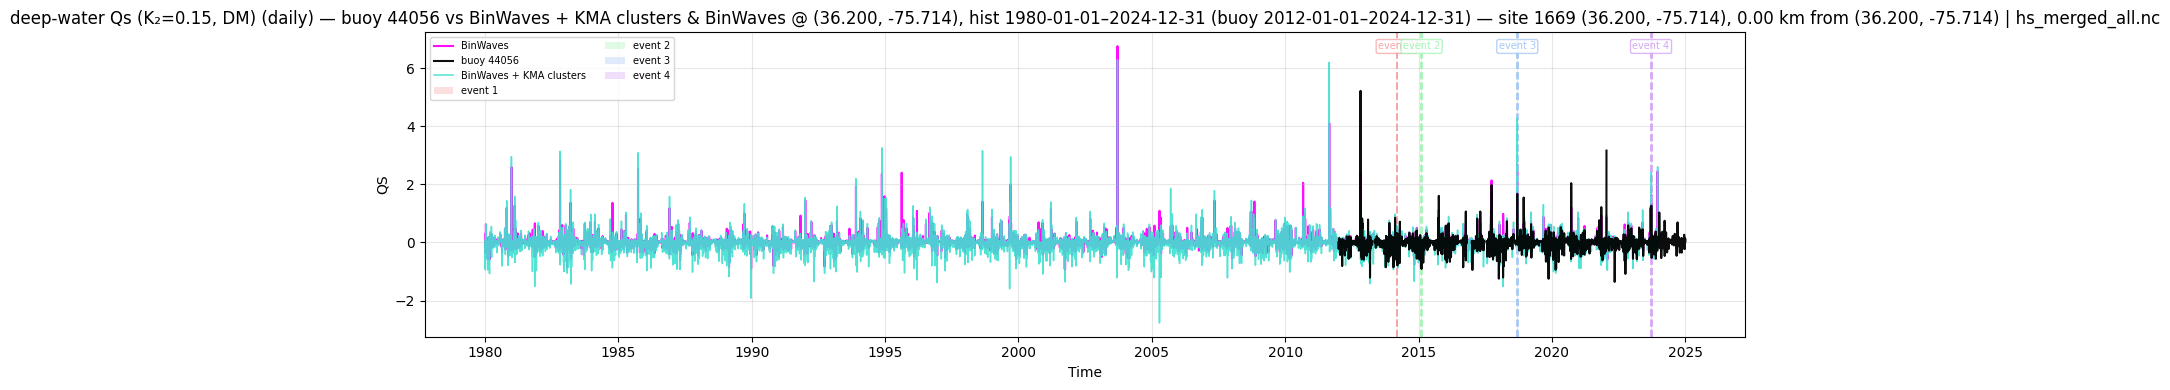

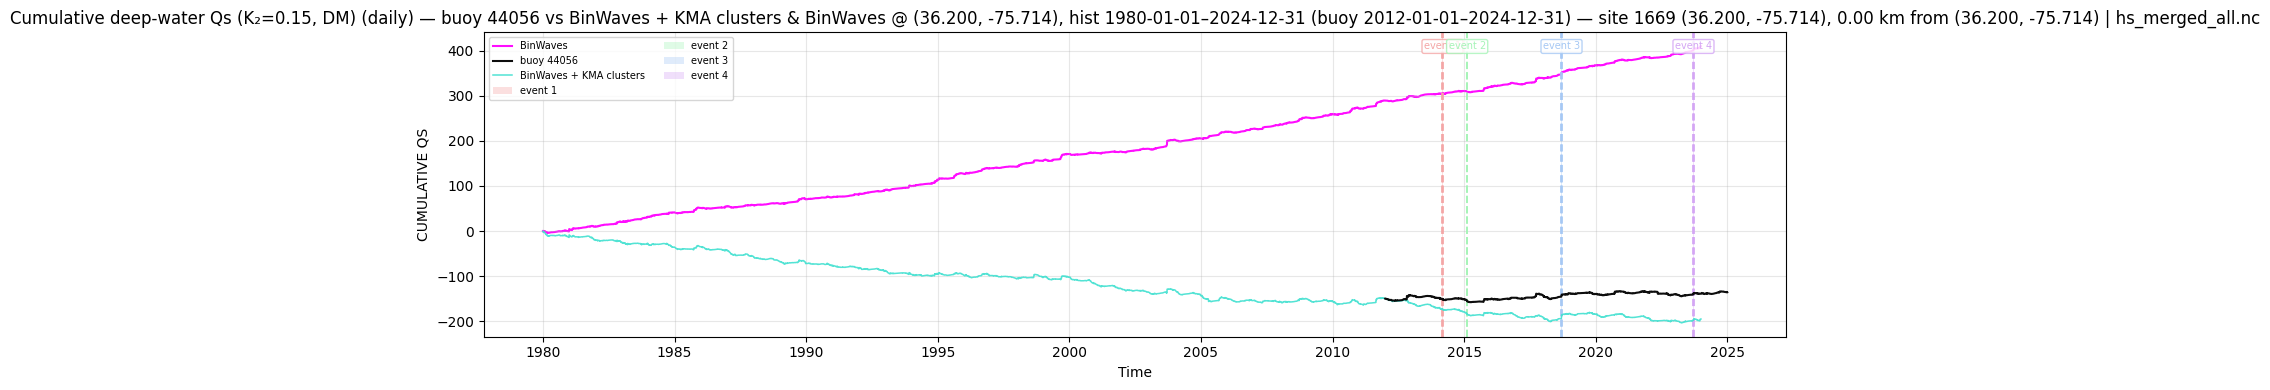

[BuoyHistoricalMatch(buoy_id='44056', buoy_lat=36.2, buoy_lon=-75.714, coordinate=(36.20000076293945, -75.71399688720703), distance_km=0.0002919098750233439, match_source='historical_grid', site_index=1669, time_start=Timestamp('2012-01-01 00:00:00'), time_end=Timestamp('2024-12-31 23:00:00'), shore_normal_deg=72.1053049927981)]

In [13]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

# wave_direction: "dp" = peak dir or "dm" = mean dir (needs dm_grid4_BinWaves_BMUS.nc in hindcast folder)
WAVE_DIRECTION = "dm"

st.plot_longshore_transport_for_buoys(
    ["44056"],
    buoys=buoys_plus,
    qs_formula="deep",
    wave_direction=WAVE_DIRECTION,
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)


Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44056 @ (36.200, -75.714) → historical (36.200, -75.714), 0.0 km [historical_grid, site 1669] | period 2012-01-01 – 2024-12-31
  Shoreline @ (36.200, -75.714) [Natural Earth coast, 2.45 km to coast]:
    Beach alongshore direction: 342.1° (from N, clockwise)
    Shore-normal seaward (toward ocean): 72.1°
    Angle used in Qs — shore-normal seaward: 72.1° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


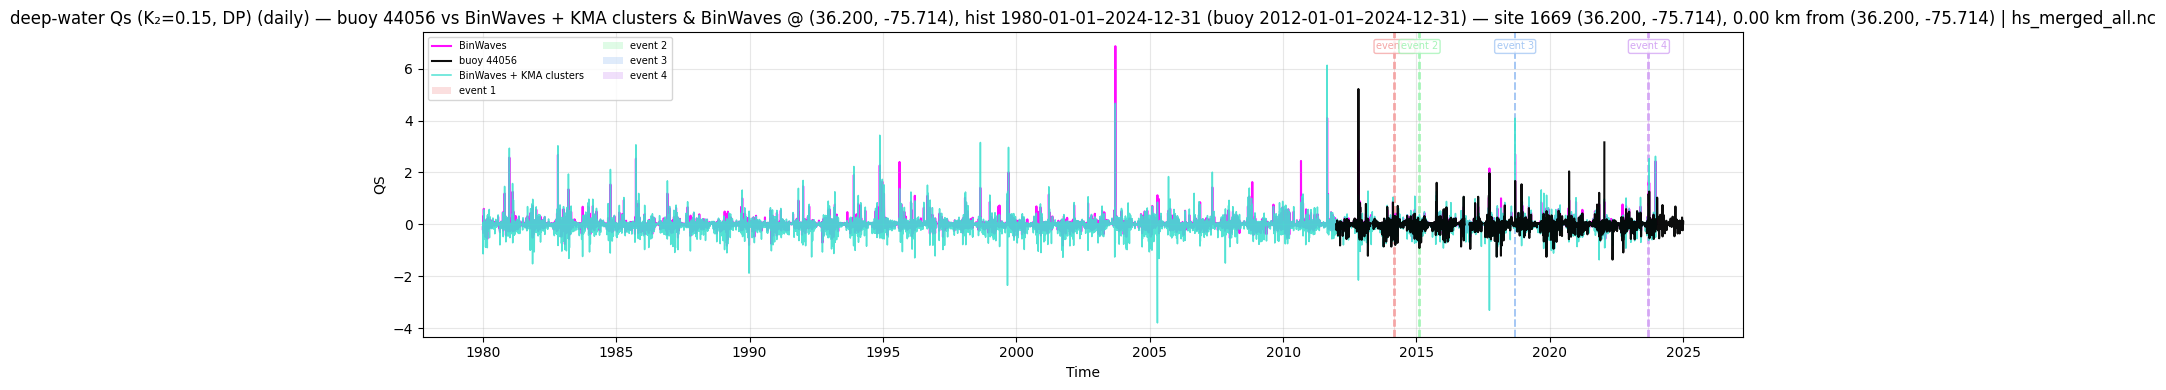

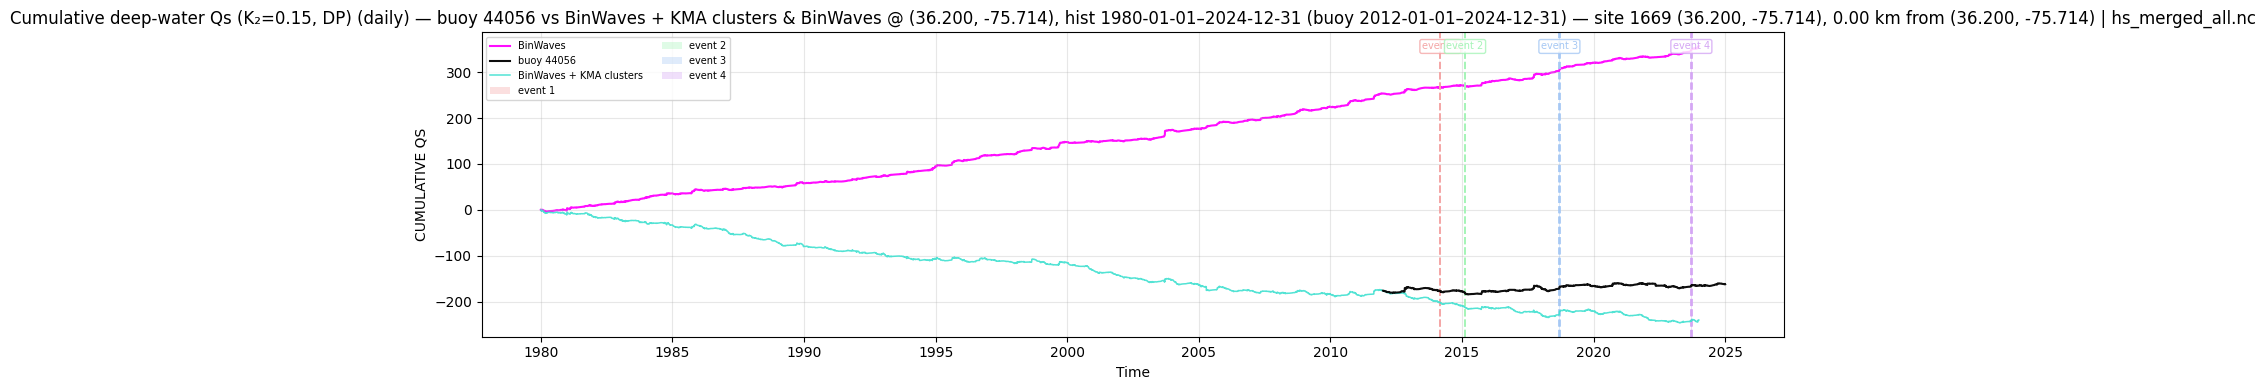

[BuoyHistoricalMatch(buoy_id='44056', buoy_lat=36.2, buoy_lon=-75.714, coordinate=(36.20000076293945, -75.71399688720703), distance_km=0.0002919098750233439, match_source='historical_grid', site_index=1669, time_start=Timestamp('2012-01-01 00:00:00'), time_end=Timestamp('2024-12-31 23:00:00'), shore_normal_deg=72.1053049927981)]

In [22]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

# wave_direction: "dp" = peak dir or "dm" = mean dir (needs dm_grid4_BinWaves_BMUS.nc in hindcast folder)
WAVE_DIRECTION = "dp"

st.plot_longshore_transport_for_buoys(
    ["44056"],
    buoys=buoys_plus,
    qs_formula="deep",
    wave_direction=WAVE_DIRECTION,
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)

Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44100 @ (36.258, -75.593) → historical (36.258, -75.593), 0.0 km [historical_grid, site 1670] | period 2008-05-23 – 2024-12-31
  Shoreline @ (36.258, -75.593) [Natural Earth coast, 14.48 km to coast]:
    Beach alongshore direction: 337.9° (from N, clockwise)
    Shore-normal seaward (toward ocean): 67.9°
    Angle used in Qs — shore-normal seaward: 67.9° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


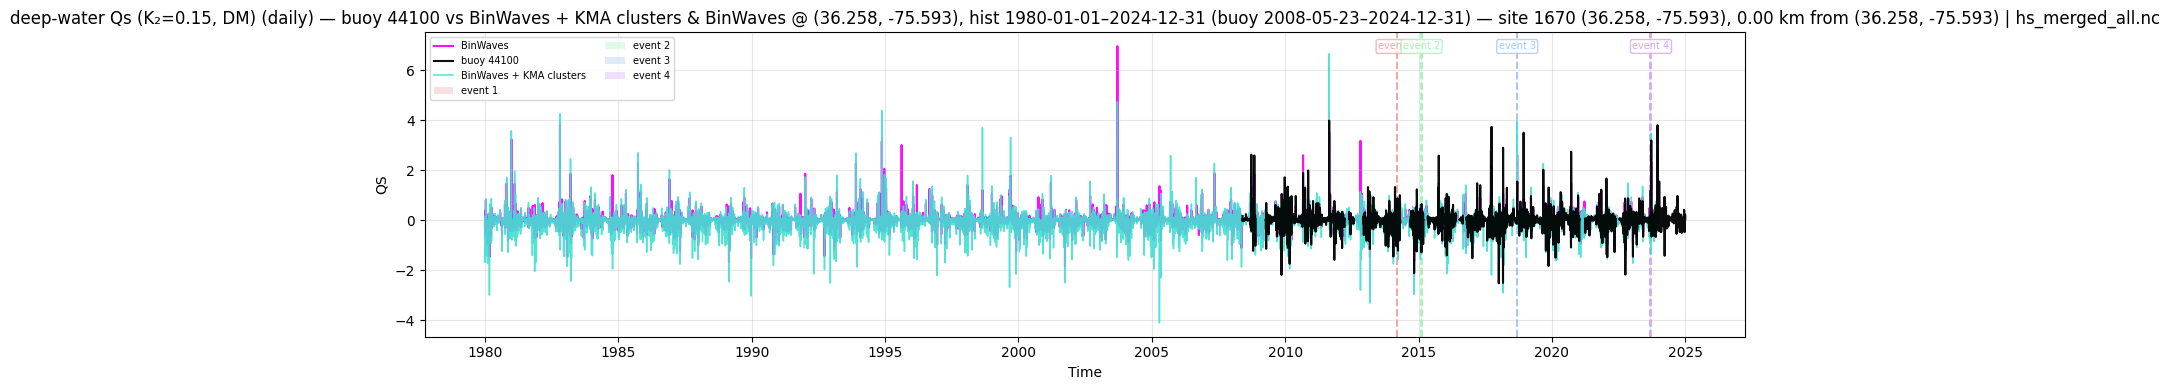

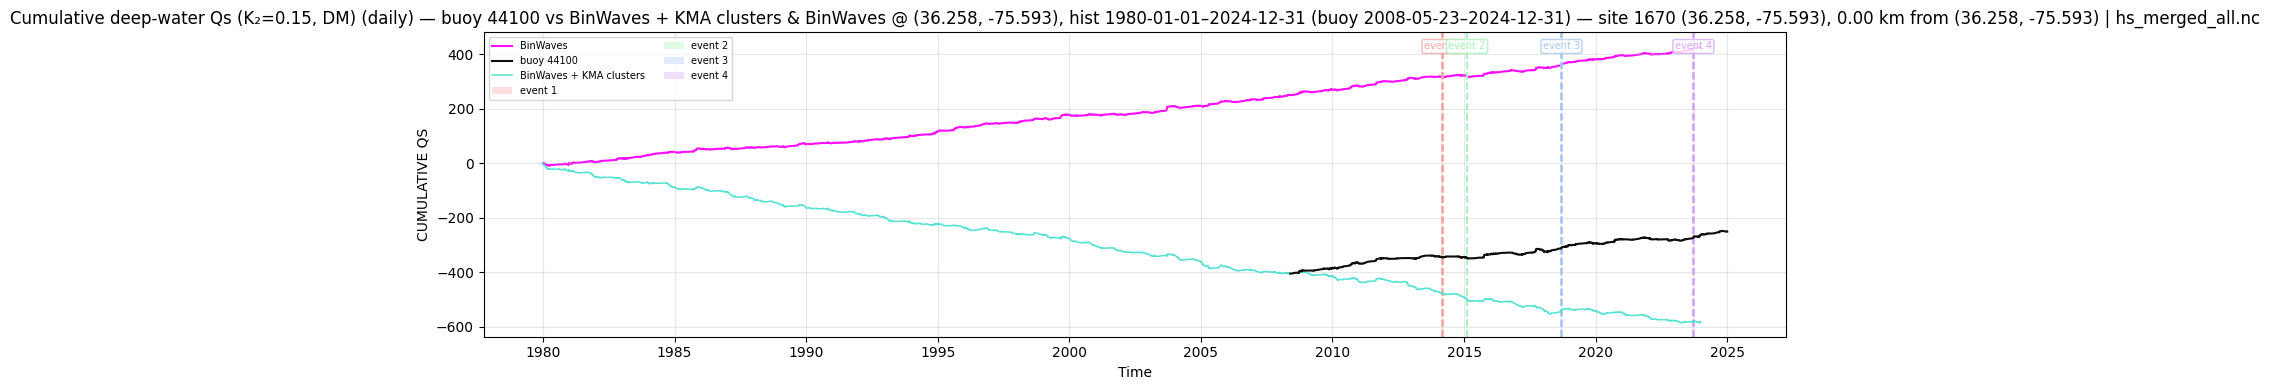

[BuoyHistoricalMatch(buoy_id='44100', buoy_lat=36.258, buoy_lon=-75.593, coordinate=(36.257999420166016, -75.59300231933594), distance_km=0.00021772486041088276, match_source='historical_grid', site_index=1670, time_start=Timestamp('2008-05-23 17:00:00'), time_end=Timestamp('2024-12-31 23:00:00'), shore_normal_deg=67.87520663436021)]

In [23]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

# wave_direction: "dp" = peak dir or "dm" = mean dir (needs dm_grid4_BinWaves_BMUS.nc in hindcast folder)
WAVE_DIRECTION = "dm"
st.plot_longshore_transport_for_buoys(
    ["44100"],
    buoys=buoys_plus,
    qs_formula="deep",
    wave_direction=WAVE_DIRECTION,
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)


Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44006 @ (36.300, -75.400) → historical (36.300, -75.400), 0.0 km [historical_grid, site 2963] | period 1994-07-26 – 1994-12-30
  Shoreline @ (36.300, -75.400) [Natural Earth coast, 31.90 km to coast]:
    Beach alongshore direction: 337.9° (from N, clockwise)
    Shore-normal seaward (toward ocean): 67.9°
    Angle used in Qs — shore-normal seaward: 67.9° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


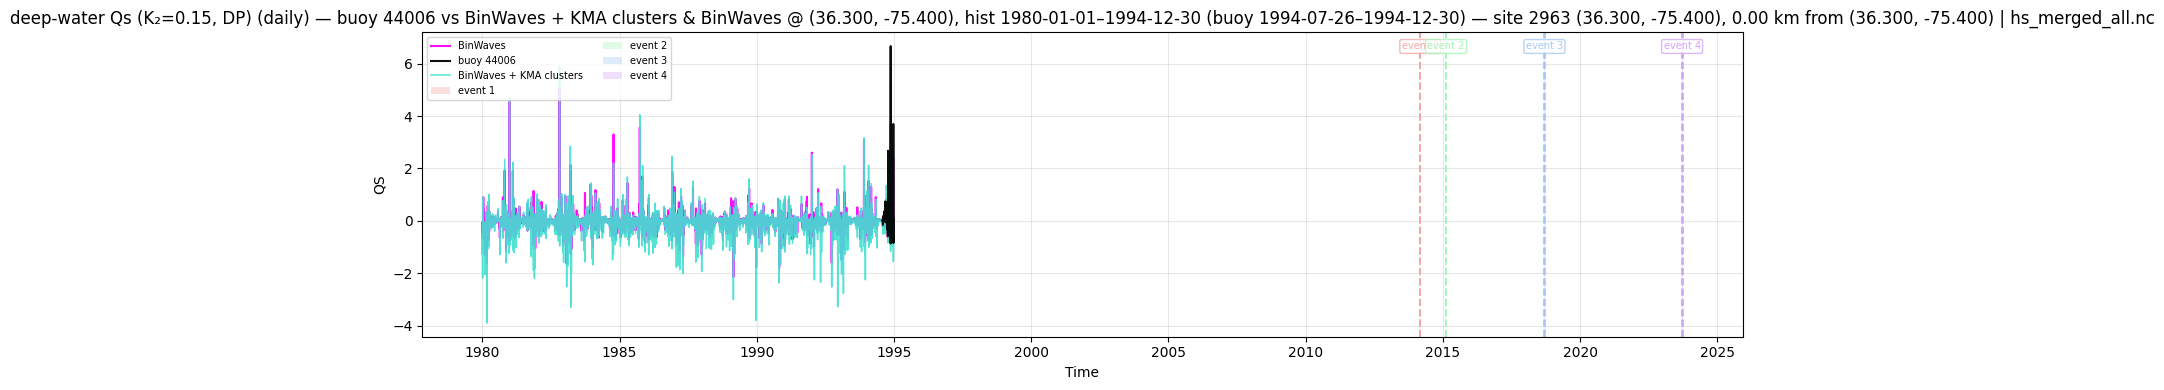

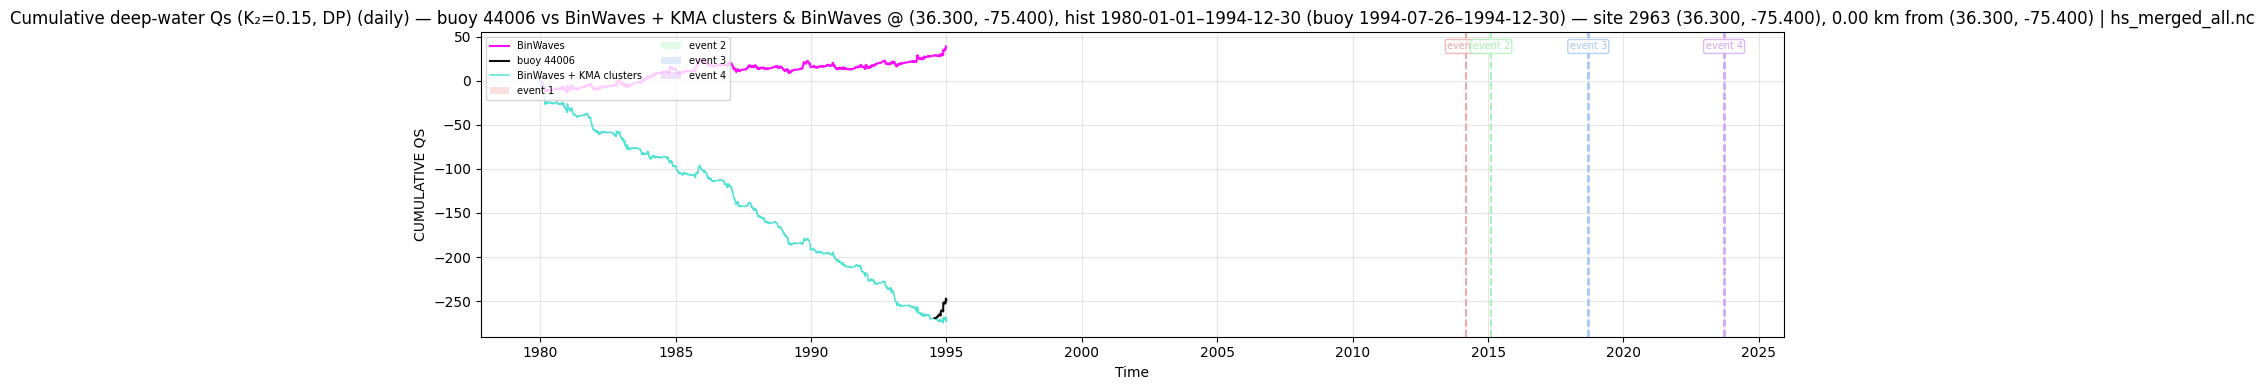

[BuoyHistoricalMatch(buoy_id='44006', buoy_lat=36.3, buoy_lon=-75.4, coordinate=(36.29999923706055, -75.4000015258789), distance_km=0.00016092019546714125, match_source='historical_grid', site_index=2963, time_start=Timestamp('1994-07-26 19:00:00'), time_end=Timestamp('1994-12-30 10:00:00'), shore_normal_deg=67.87520663436021)]

In [24]:
st.plot_longshore_transport_for_buoys(
    ["44006"],
    buoys=buoys_plus,
    qs_formula="deep",
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)


Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44019 @ (36.400, -75.200) → historical (36.400, -75.200), 0.0 km [historical_grid, site 2964] | period 1994-08-01 – 1995-03-12
  Shoreline @ (36.400, -75.200) [Natural Earth coast, 51.85 km to coast]:
    Beach alongshore direction: 337.9° (from N, clockwise)
    Shore-normal seaward (toward ocean): 67.9°
    Angle used in Qs — shore-normal seaward: 67.9° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


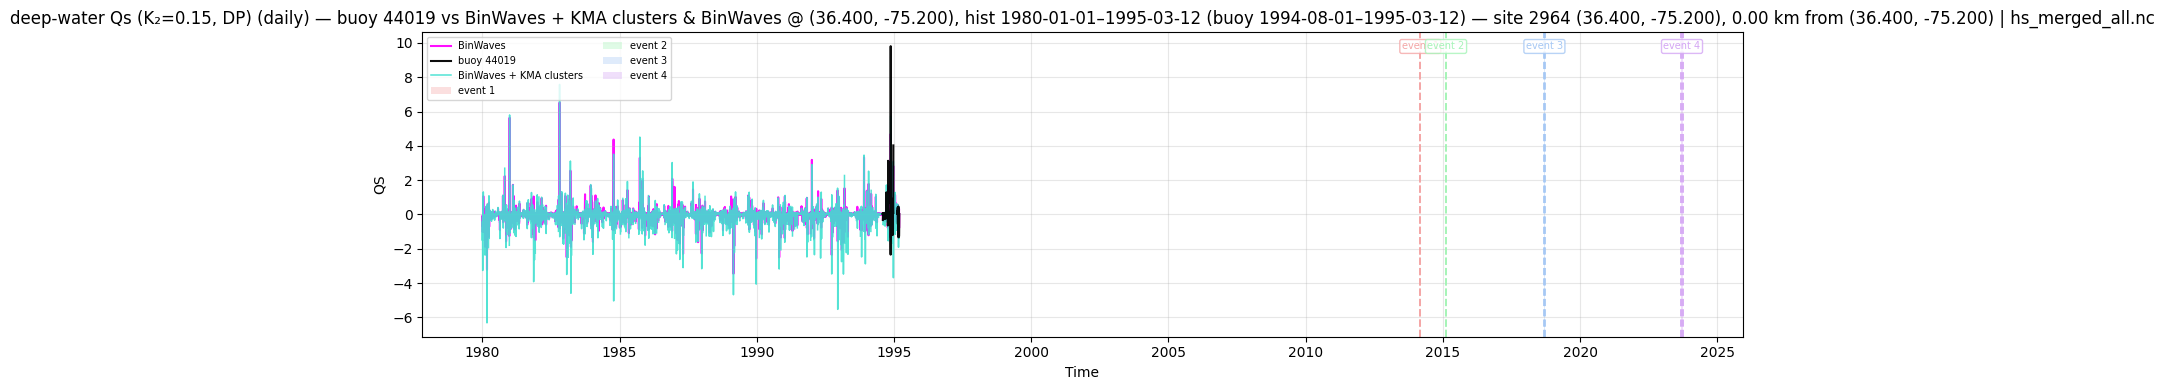

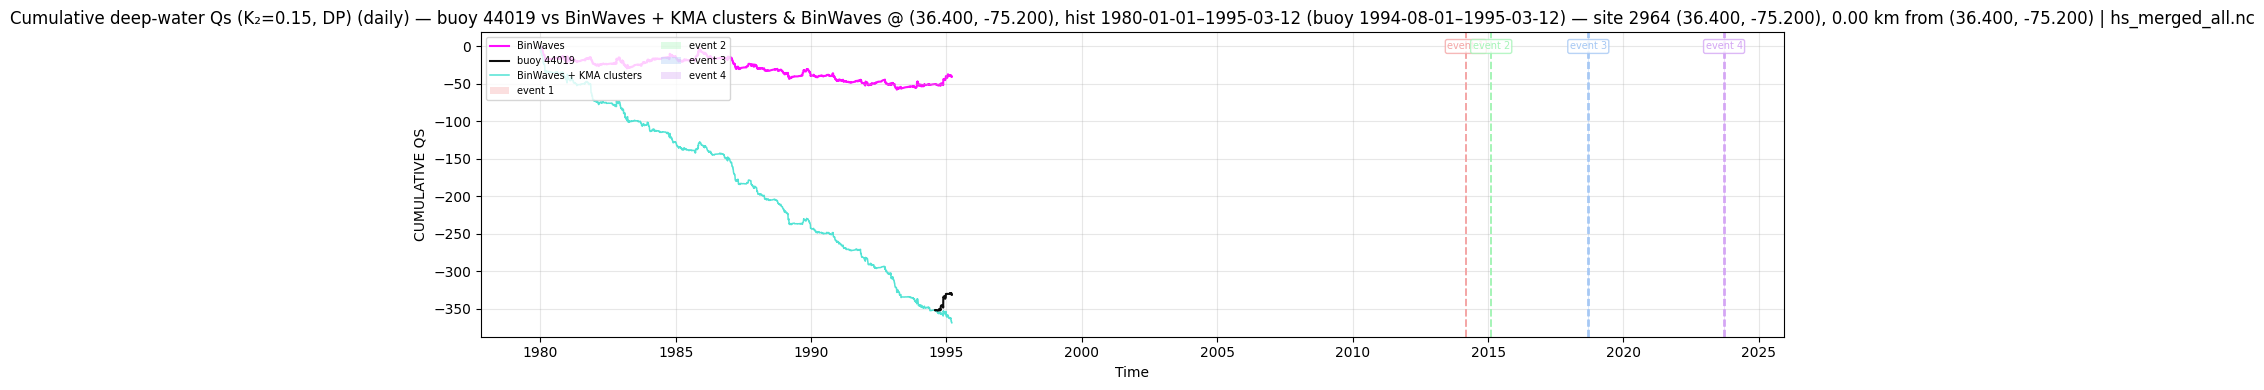

[BuoyHistoricalMatch(buoy_id='44019', buoy_lat=36.4, buoy_lon=-75.2, coordinate=(36.400001525878906, -75.19999694824219), distance_km=0.000321542142957192, match_source='historical_grid', site_index=2964, time_start=Timestamp('1994-08-01 18:00:00'), time_end=Timestamp('1995-03-12 22:00:00'), shore_normal_deg=67.87520663436021)]

In [25]:
st.plot_longshore_transport_for_buoys(
    ["44019"],
    buoys=buoys_plus,
    qs_formula="deep",
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)


Buoy Qs hindcast folder: /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | bulk series: 'BinWaves + KMA clusters' | BinWaves reference: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Buoy 44014 @ (36.603, -74.837) → historical (36.579, -74.813), 3.4 km [historical_grid, site 2960] | period 1991-07-03 – 2024-12-31
  Shoreline @ (36.579, -74.813) [Natural Earth coast, 89.50 km to coast]:
    Beach alongshore direction: 348.1° (from N, clockwise)
    Shore-normal seaward (toward ocean): 78.1°
    Angle used in Qs — shore-normal seaward: 78.1° (alpha = Dp − angle; convention='seaward')
Using requested partition_ids: []


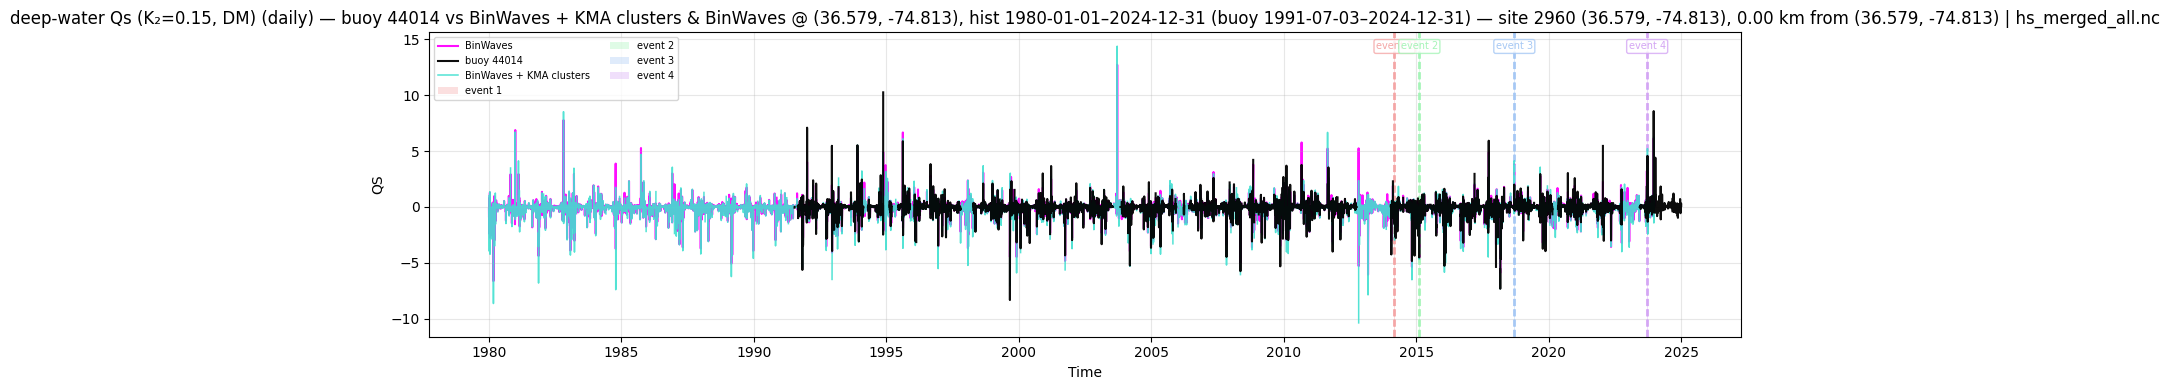

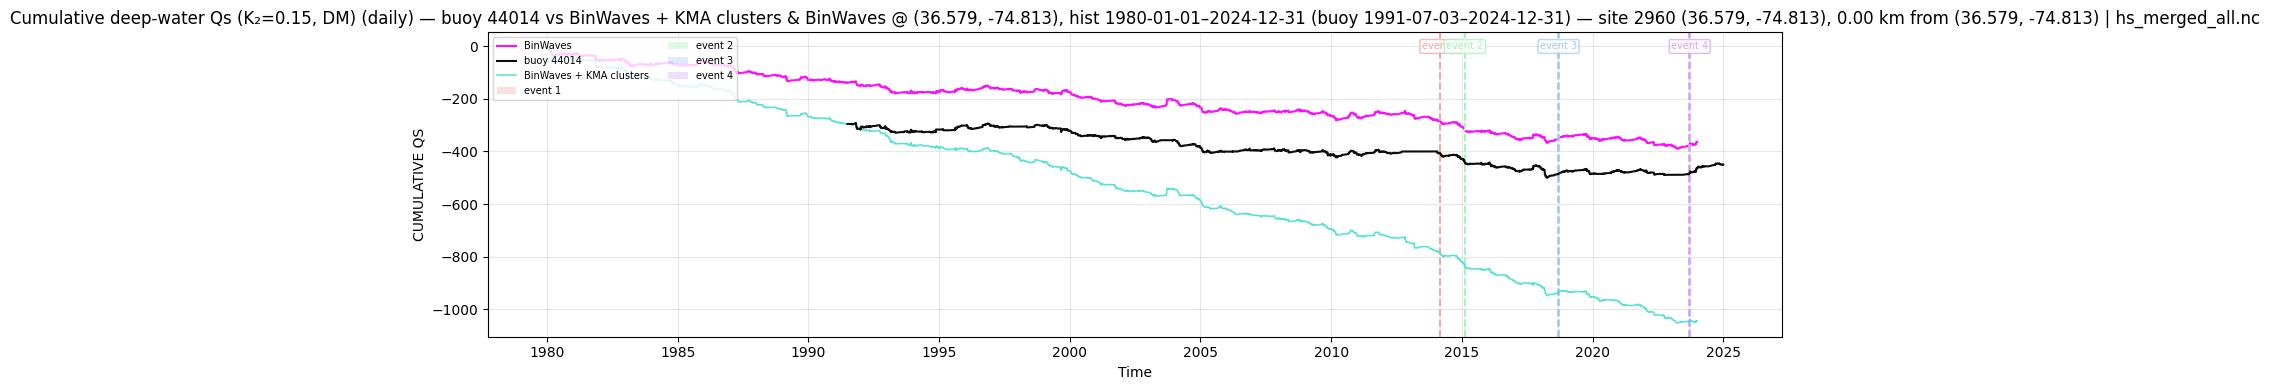

[BuoyHistoricalMatch(buoy_id='44014', buoy_lat=36.603, buoy_lon=-74.837, coordinate=(36.579044342041016, -74.81298828125), distance_km=3.4192463471841195, match_source='historical_grid', site_index=2960, time_start=Timestamp('1991-07-03 16:00:00'), time_end=Timestamp('2024-12-31 23:00:00'), shore_normal_deg=78.1132300051193)]

In [26]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

# wave_direction: "dp" = peak dir or "dm" = mean dir (needs dm_grid4_BinWaves_BMUS.nc in hindcast folder)
WAVE_DIRECTION = "dm"

st.plot_longshore_transport_for_buoys(
    ["44014"],
    buoys=buoys_plus,
    qs_formula="deep",
    wave_direction=WAVE_DIRECTION,
    K=0.15,
    aggregation="daily",
    include_partitions=False,
    cumulative_reference_start="1980-01-01",
    time_highlights=[
        ("2014-03-06", "2014-03-08", "#f4a6a6", "event 1"),
        ("2015-02-09", "2015-02-15", "#a6f4b8", "event 2"),
        ("2018-09-10", "2018-09-17", "#a6c8f4", "event 3"),
        ("2023-09-12", "2023-09-26", "#d4a6f4", "event 4"),
    ],
    **_HIST_KW,
)


### Partition Hs/Tp/Dp + Qs with **BinWaves + KMA cluster SWAN**

For each hour, the nearest 3-hourly BMU is looked up in `outputs/KMA/nearest_centroids_idxs_kma_pcs.csv`,
then SWAN bulk parameters are read from the matching static case `inputs/CASES_ONLY_WIND/{bmu:03d}/output.mat`.
Wind-sea from those cluster runs is combined with BinWaves hindcast bulk (same rule as `input_data_check.ipynb`).
The combined series is overlaid on the bulk column (turquoise line).

In [ ]:
# `_HIST_KW` is defined in the BinWaves_BMUS setup cell (cell 3).


Note: hourly/native resolution — large plots (~10⁵ points per series). Use aggregation='daily' or 'monthly' for faster summaries.
Partition Hs/Tp/Dp — partitions_folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Partition Hs/Tp/Dp — historical_folder (bulk): /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | 'BinWaves + KMA clusters'
Partition Hs/Tp/Dp — BinWaves reference folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Coordinate (lat, lon) = (36.200, -75.714)


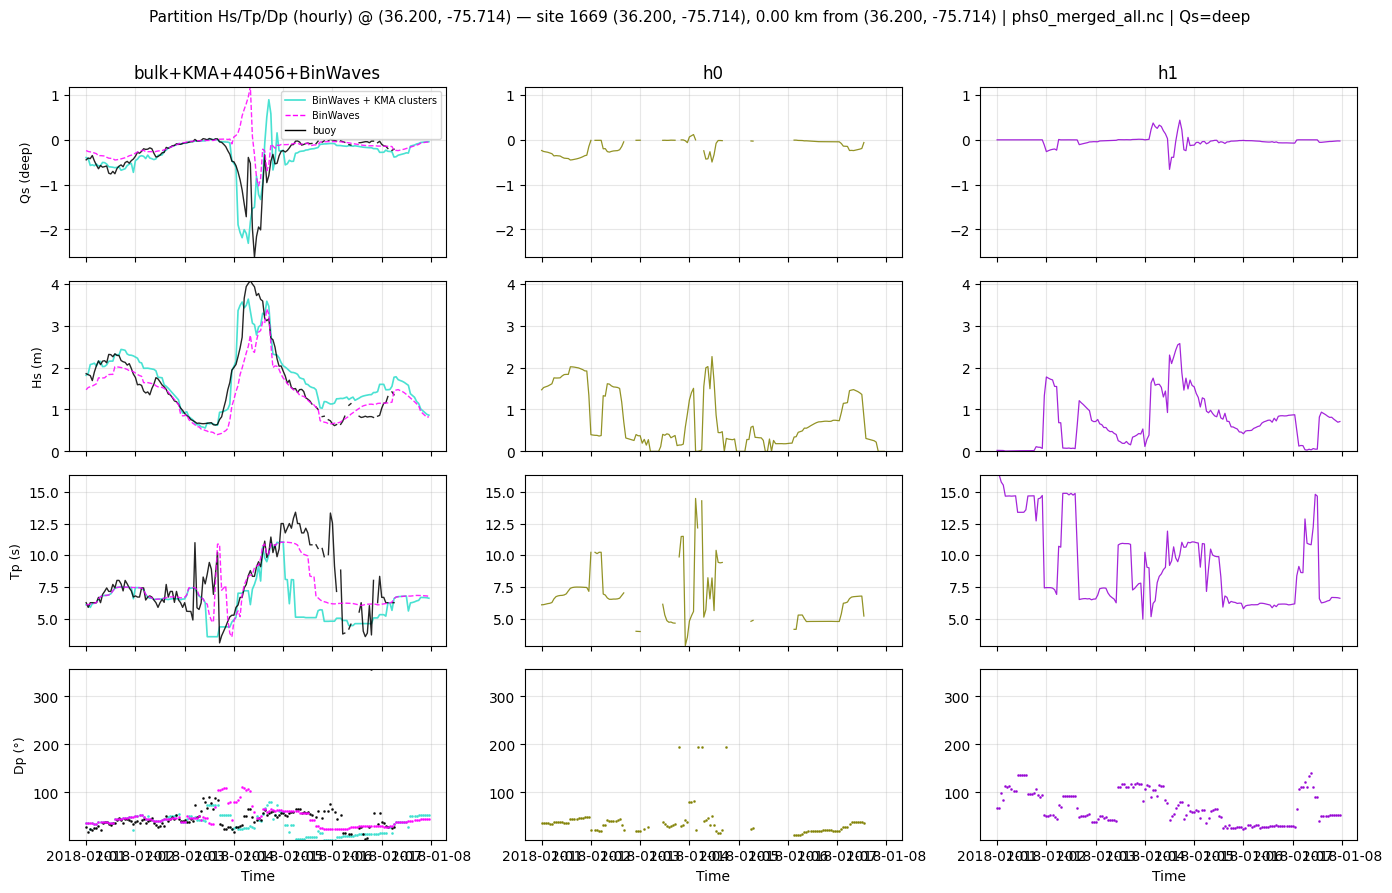

In [27]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    # [(-74.813, 36.579)],
    [(-75.714, 36.2)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44056",
    partition_ids=[0, 1],
    time_start="2018-01-01",
    time_end="2018-01-07",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


Note: hourly/native resolution — large plots (~10⁵ points per series). Use aggregation='daily' or 'monthly' for faster summaries.
Partition Hs/Tp/Dp — partitions_folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Partition Hs/Tp/Dp — historical_folder (bulk): /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | 'BinWaves + KMA clusters'
Partition Hs/Tp/Dp — BinWaves reference folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Coordinate (lat, lon) = (36.200, -75.714)


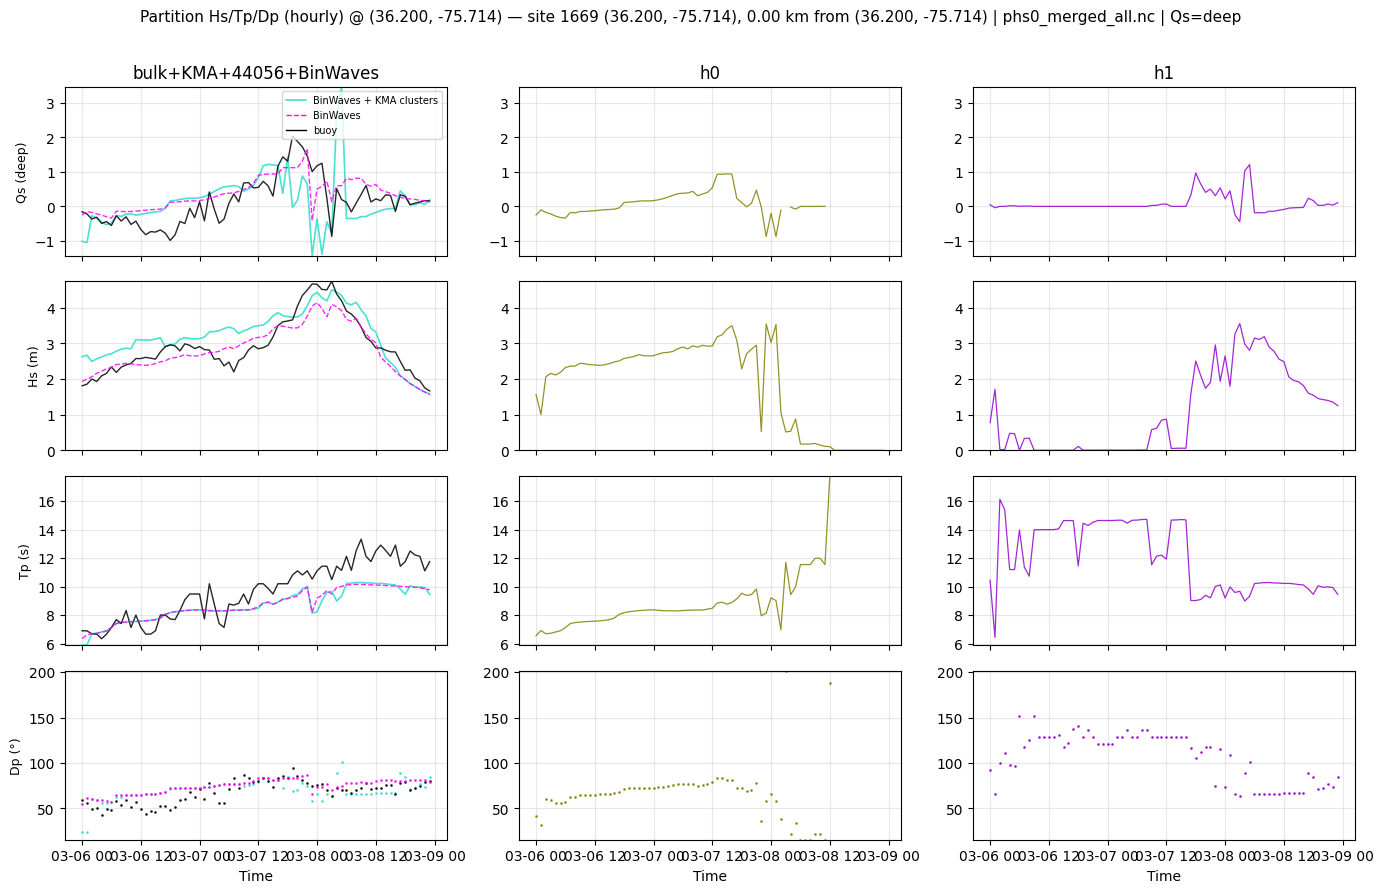

In [19]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-75.714, 36.2)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44056",
    partition_ids=[0, 1],
    time_start="2014-03-06",
    time_end="2014-03-08",
    interactive=False,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


Note: hourly/native resolution — large plots (~10⁵ points per series). Use aggregation='daily' or 'monthly' for faster summaries.
Partition Hs/Tp/Dp — partitions_folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Partition Hs/Tp/Dp — historical_folder (bulk): /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | 'BinWaves + KMA clusters'
Partition Hs/Tp/Dp — BinWaves reference folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Coordinate (lat, lon) = (36.258, -75.593)


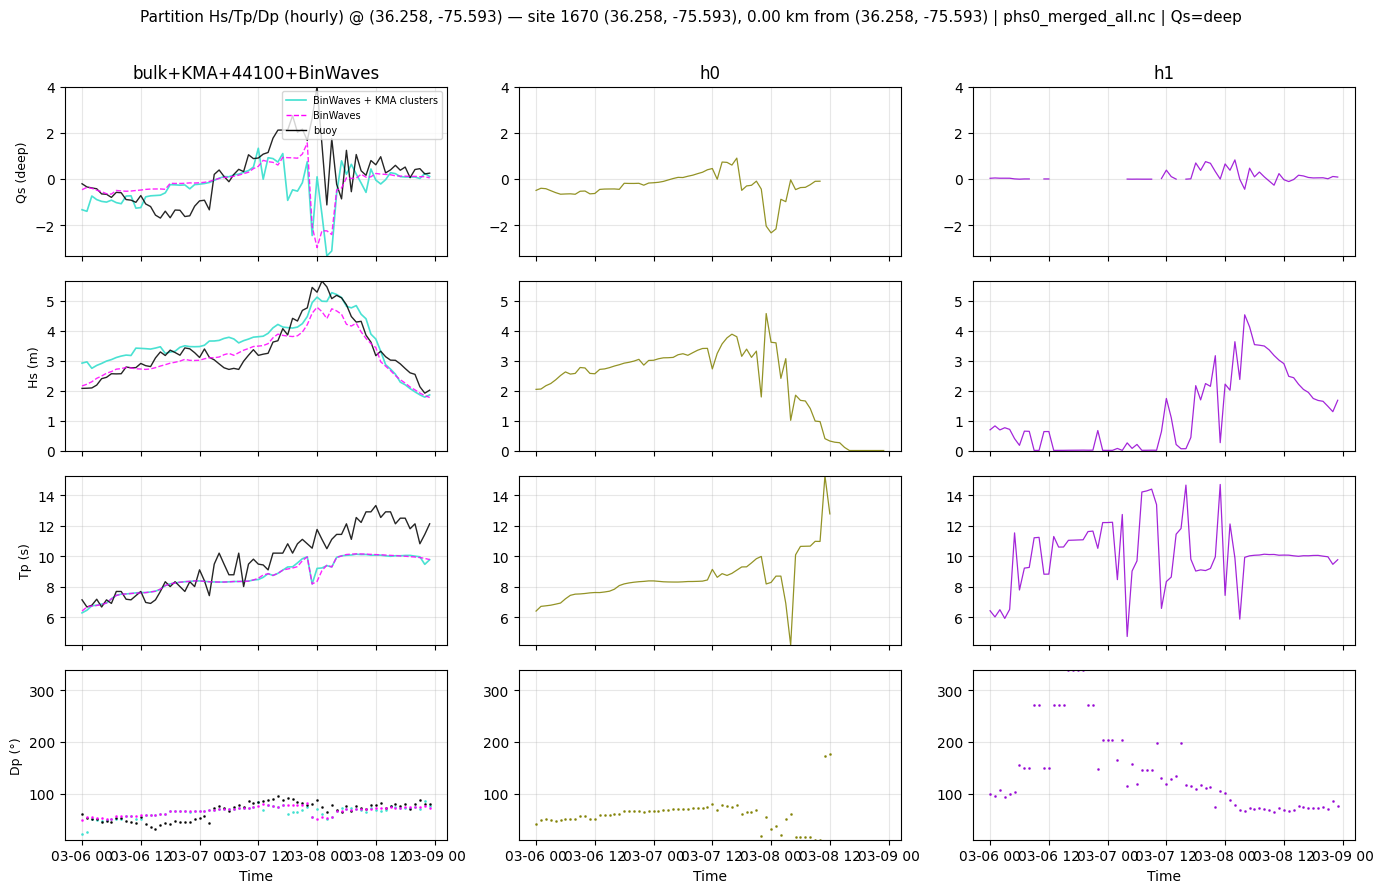

In [20]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-75.593, 36.258)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44100",
    partition_ids=[0, 1],
    time_start="2014-03-06",
    time_end="2014-03-08",
    interactive=False,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


Note: hourly/native resolution — large plots (~10⁵ points per series). Use aggregation='daily' or 'monthly' for faster summaries.
Partition Hs/Tp/Dp — partitions_folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Partition Hs/Tp/Dp — historical_folder (bulk): /lustre/geocean/WORK/users/montanoj/personal/Wind_Metamodel/outputs/merged_grids_binwaves_bmus | 'BinWaves + KMA clusters'
Partition Hs/Tp/Dp — BinWaves reference folder: /nfs/home/geocean/montanoj/ShoreShop2026/outputs/merged_grids
Coordinate (lat, lon) = (36.579, -74.813)


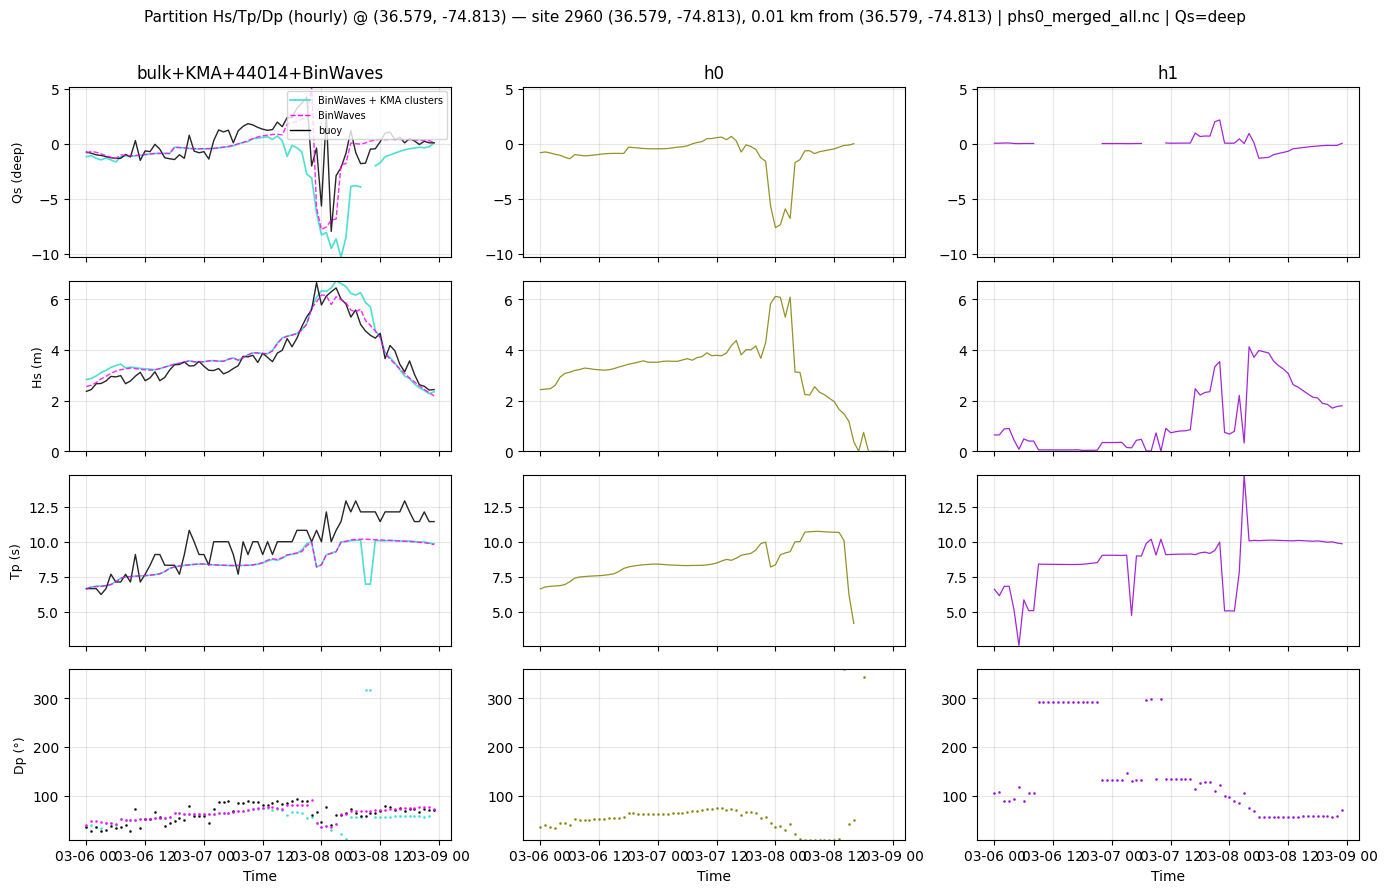

In [21]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-74.813, 36.579)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44014",
    partition_ids=[0, 1],
    time_start="2014-03-06",
    time_end="2014-03-08",
    interactive=False,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [1]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-75.714, 36.2)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44056",
    partition_ids=[0, 1],
    time_start="2023-09-12",
    time_end="2023-09-26",
    interactive=False,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


NameError: name '_HIST_KW' is not defined

In [ ]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-75.593, 36.258)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44100",
    partition_ids=[0, 1],
    time_start="2023-09-12",
    time_end="2023-09-26",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-74.813, 36.579)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44014",
    partition_ids=[0, 1],
    time_start="2023-09-12",
    time_end="2023-09-26",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-75.714, 36.2)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44056",
    partition_ids=[0, 1],
    time_start="2015-02-09",
    time_end="2015-02-15",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-74.813, 36.579)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44014",
    partition_ids=[0, 1],
    time_start="2015-02-09",
    time_end="2015-02-15",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
st.plot_partition_hs_tp_dp_timeseries(
    [(-75.714, 36.2)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44056",
    partition_ids=[0, 1],
    time_start="2018-09-10", 
    time_end="2018-09-17",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
import importlib
import utils.sediment_transport_NC as st
importlib.reload(st)

_buoy_kw = {"buoys": buoys} if "buoys" in globals() else {}

st.plot_partition_hs_tp_dp_timeseries(
    [(-74.813, 36.579)],
    qs_formula="deep",  # or "cerc"
    aggregation="hourly",
    layout="grid",
    grid_orientation="rows_are_variables",
    include_sediment_transport_row=True,
    shoreline_orientation_deg=69,
    K=0.15,
    include_bulk=True,
    include_buoy=True,
    buoy_id="44014",
    partition_ids=[0, 1],
    time_start="2018-09-10", 
    time_end="2018-09-17",
    interactive=True,
    static=True,
    **_buoy_kw,
    **_HIST_KW,
)


In [ ]:
import utils.sediment_transport_NC as st
import importlib
importlib.reload(st)

# Shared % grid for energy roses (right panel)
ROSE_RADIAL = "0:4:28"  # 5%, 10%, …, 25%

# Hindcast wave rose inputs — pick folder and direction variable
HINDCAST_ROSE_KW = _HIST_KW
WAVE_DIRECTION = "dp"  # "dp" peak dir or "dm" mean dir (needs dm_grid4_BinWaves_BMUS.nc)

st.plot_buoy_wave_rose(
    "44056",
    time_start="2012-01-01",
    time_end="2023-12-31",
    aggregation="hourly",
    n_dir_bins=24,
    shoreline_orientation_deg=72,
    radial_range=ROSE_RADIAL,
)

st.plot_historical_wave_rose(
    coordinate=(36.20, -75.714),
    wave_direction=WAVE_DIRECTION,
    time_start="2012-01-01",
    time_end="2023-12-31",
    aggregation="hourly",
    n_dir_bins=24,
    shoreline_orientation_deg=72,
    radial_range=ROSE_RADIAL,
    **HINDCAST_ROSE_KW,
)

# st.plot_historical_partition_wave_rose(
#     coordinate=(36.20, -75.714),
#     partition_ids=(0, 1),
#     shoreline_orientation_deg=72,
#     n_dir_bins=24,
#     aggregation="hourly",
#     time_start="2012-01-01",
#     time_end="2023-12-31",
#     radial_range=ROSE_RADIAL,
# )
